### Store Sales Business Analysis 
## Executive Purpose
Analyzing Sales data to find relavent patterns and answer Business Questions:
- Why profits are low even though Sales are increasing?
- Detailed analysis on sales to find relavant insights like 'Where business growing ?' and 'What products are sold more ?'
- Where profit is more and what are the factors effecting the profits ?

In [388]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [389]:
df = pd.read_csv('C:/Users/nitin/OneDrive/Desktop/Data Analyst/Data/Sample_Superstore.csv',sep=',',encoding='cp1252')

# Dataset
- Raw rows : 9993
- Raw Columns : 21

In [413]:
display(df.head())
display(df.tail())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,time
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,2015-10


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,time
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028,2014,January,2014-01
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332,2017,February,2017-02
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,2017,February,2017-02
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,2017,February,2017-02
9993,9994,CA-2017-119914,2017-05-04,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,2017,May,2017-05


In [391]:
summary = pd.DataFrame({
    'dtype' : df.dtypes,
    'missing' : df.isna().sum(),
    'missing_%': df.isna().mean()*100,
    'unique' : df.nunique()
})
summary

,dtype,missing,missing_%,unique
Row ID,int64,0,0.0,9994
Order ID,object,0,0.0,5009
Order Date,object,0,0.0,1237
Ship Date,object,0,0.0,1334
Ship Mode,object,0,0.0,4
Customer ID,object,0,0.0,793
Customer Name,object,0,0.0,793
Segment,object,0,0.0,3
Country,object,0,0.0,1
City,object,0,0.0,531


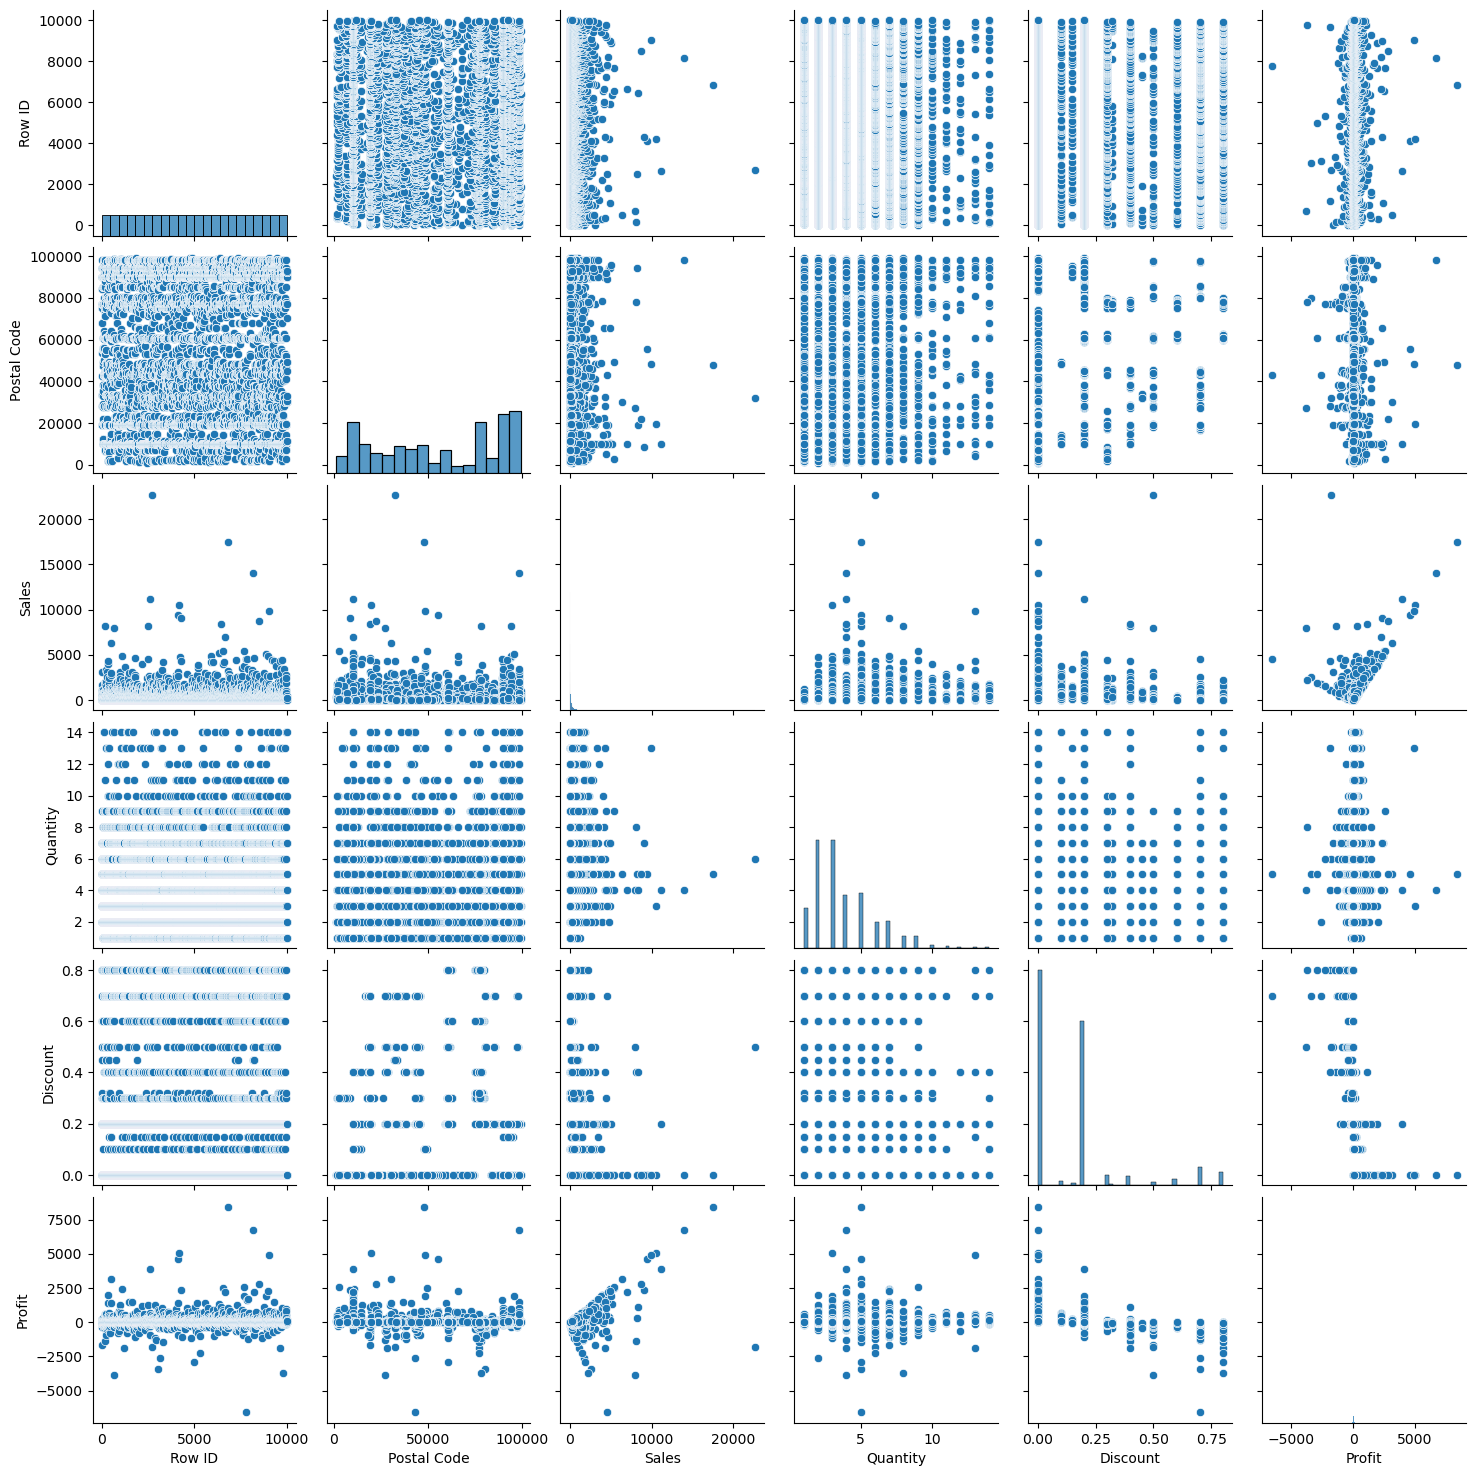

In [392]:
df_numeric = df.select_dtypes('number')
sns.pairplot(df_numeric)

In [393]:
correlation = (df_numeric.corr()).round(2)
filtered = correlation[correlation >0.3 ]

<Axes: >

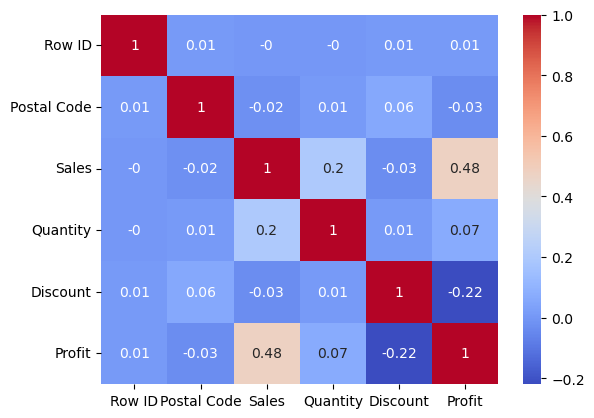

In [394]:
sns.heatmap(correlation,cmap='coolwarm',annot=True)

# Key finding 
- Sales has positive moderate correalation with profit
- discount has negative correlation with profit

In [415]:
raw = df.copy()
raw['Disband'] =pd.cut(
    df['Discount'],
    bins=[-0.01,0,0.2,0.4,1],
    labels=['0','1 20','21 40',40]
)
raw.groupby('Disband')['Profit'].agg(['sum','mean','count'])

C:\Users\nitin\AppData\Local\Temp\ipykernel_21928\3781654842.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby('Disband')['Profit'].agg(['sum','mean','count'])


,sum,mean,count
Disband,,,
0,320987.6032,66.900292,4798
1 20,100785.4745,26.501571,3803
21 40,-35817.4655,-77.864055,460
40,-99558.5905,-106.708028,933


In [395]:
def others(row):
    row['revenue_%'] =(row['revenue']/row['revenue'].sum() *100 ).round(2)
    row['aov'] = (row['revenue']/row['orders'].sum() *100 ).round(2)
    row['margin_%'] = (row['profit']/row['revenue'] *100 ).round(2)
    return row 

In [396]:

state_chart = df.groupby('State').agg(
    orders = ('Order ID','nunique'),
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    profit = ('Profit','sum'),
    ).sort_values('revenue',ascending=True)
state_chart = others(state_chart)
state_chart.sort_values('revenue',ascending=False)

,orders,revenue,Quantity,profit,revenue_%,aov,margin_%
State,,,,,,,
California,1021,457687.6315,7667,76381.3871,19.92,9137.31,16.69
New York,562,310876.2710,4224,74038.5486,13.53,6206.35,23.82
Texas,487,170188.0458,3724,-25729.3563,7.41,3397.65,-15.12
Washington,256,138641.2700,1883,33402.6517,6.04,2767.84,24.09
Pennsylvania,288,116511.9140,2153,-15559.9603,5.07,2326.05,-13.35
Florida,200,89473.7080,1379,-3399.3017,3.89,1786.26,-3.80
Illinois,276,80166.1010,1845,-12607.8870,3.49,1600.44,-15.73
Ohio,236,78258.1360,1759,-16971.3766,3.41,1562.35,-21.69
Michigan,117,76269.6140,946,24463.1876,3.32,1522.65,32.07


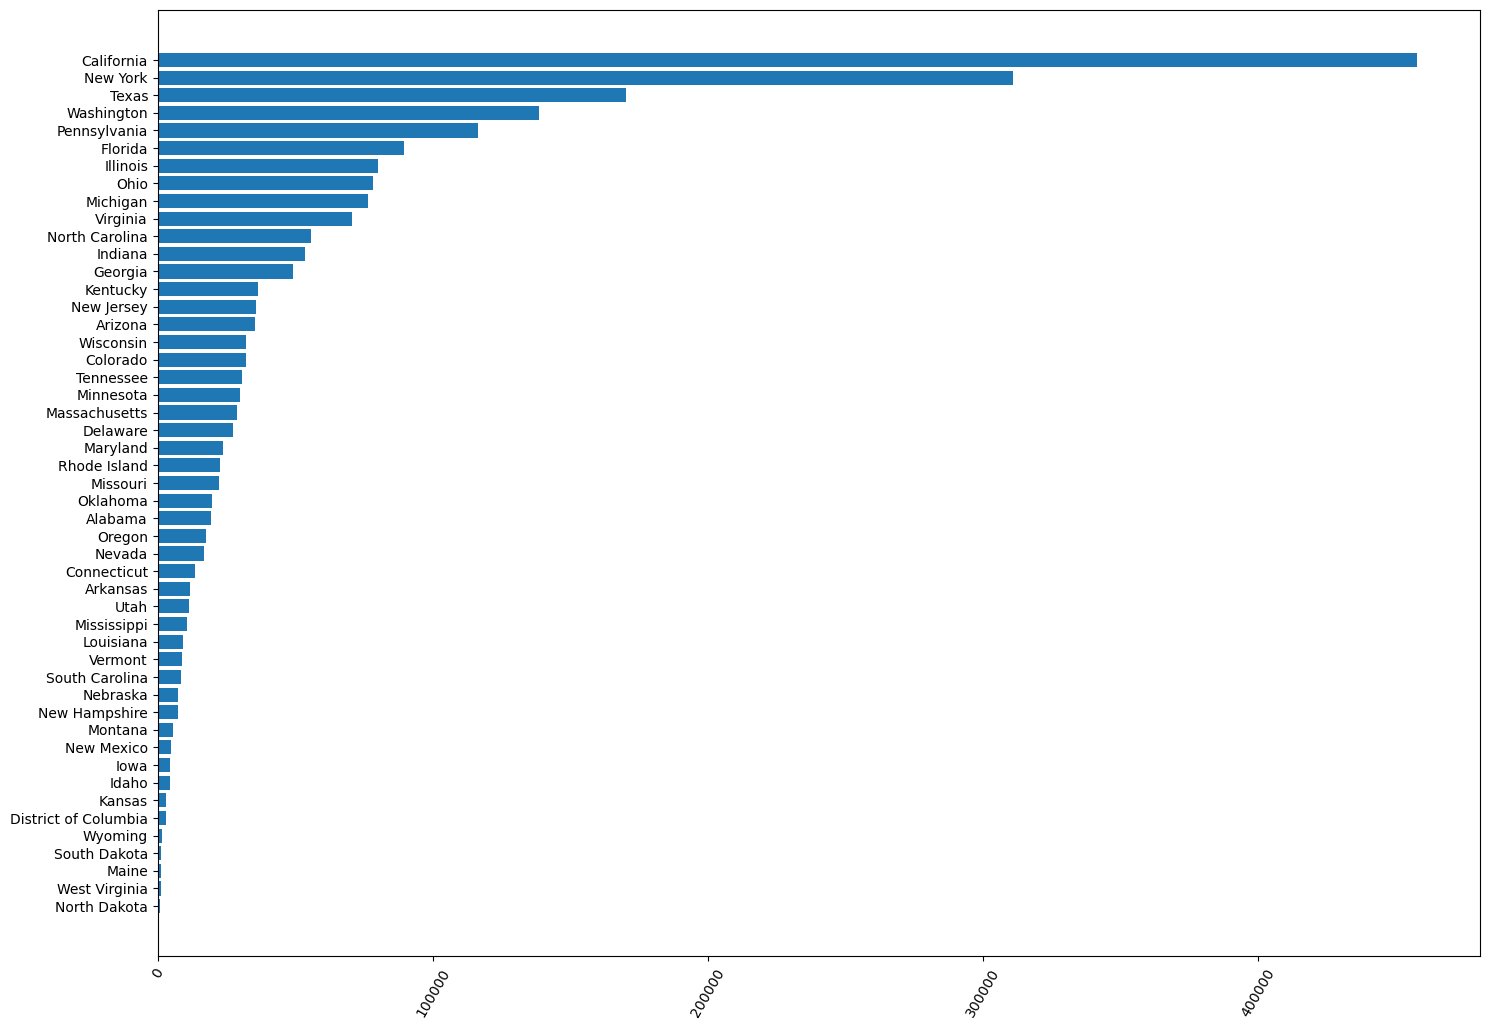

In [397]:
state_chart = state_chart.reset_index()
plt.figure(figsize=(15,10))
plt.barh(state_chart['State'],state_chart['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [398]:
# print(df['Category'].nunique())
category_chart = df.groupby('Category').agg(
    orders = ('Order ID','nunique'),
    revenue = ('Sales','sum'),
        Quantity = ('Quantity','sum'),
        profit = ('Profit','sum'),
        
).sort_values('revenue',ascending=True)
category_chart = others(category_chart)
category_chart.sort_values('revenue',ascending=False)

,orders,revenue,Quantity,profit,revenue_%,aov,margin_%
Category,,,,,,,
Technology,1544,836154.0330,6939,145454.9481,36.4,11860.34,17.40
Furniture,1764,741999.7953,8028,18451.2728,32.3,10524.82,2.49
Office Supplies,3742,719047.0320,22906,122490.8008,31.3,10199.25,17.04


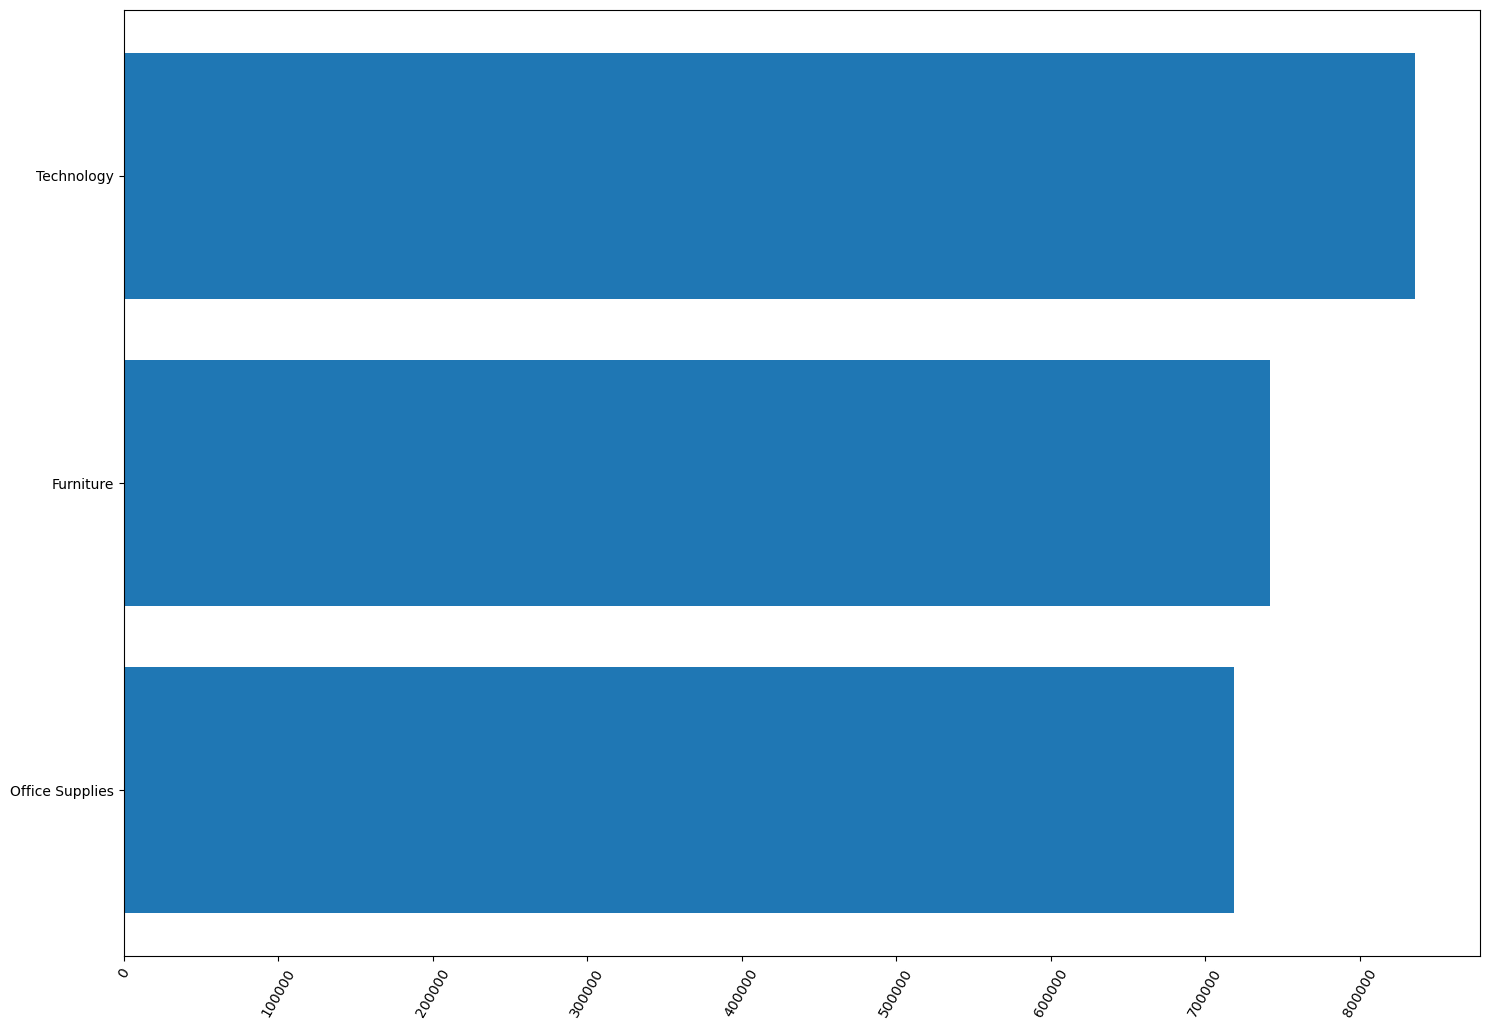

In [399]:
category_chart = category_chart.reset_index()
plt.figure(figsize=(15,10))
plt.barh(category_chart['Category'],category_chart['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [400]:
Sub_Category_chart = df.groupby('Sub-Category').agg(
    orders = ('Order ID','nunique'),
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    profit = ('Profit','sum'),
   
).sort_values('revenue',ascending=False)
Sub_Category_chart = others(Sub_Category_chart)

Sub_Category_chart

,orders,revenue,Quantity,profit,revenue_%,aov,margin_%
Sub-Category,,,,,,,
Phones,814,330007.0540,3289,44515.7306,14.37,3603.09,13.49
Chairs,576,328449.1030,2356,26590.1663,14.30,3586.08,8.10
Storage,777,223843.6080,3158,21278.8264,9.74,2443.97,9.51
Tables,307,206965.5320,1241,-17725.4811,9.01,2259.70,-8.56
Binders,1316,203412.7330,5974,30221.7633,8.85,2220.91,14.86
Machines,112,189238.6310,440,3384.7569,8.24,2066.15,1.79
Accessories,718,167380.3180,2976,41936.6357,7.29,1827.50,25.05
Copiers,68,149528.0300,234,55617.8249,6.51,1632.58,37.20
Bookcases,224,114879.9963,868,-3472.5560,5.00,1254.29,-3.02


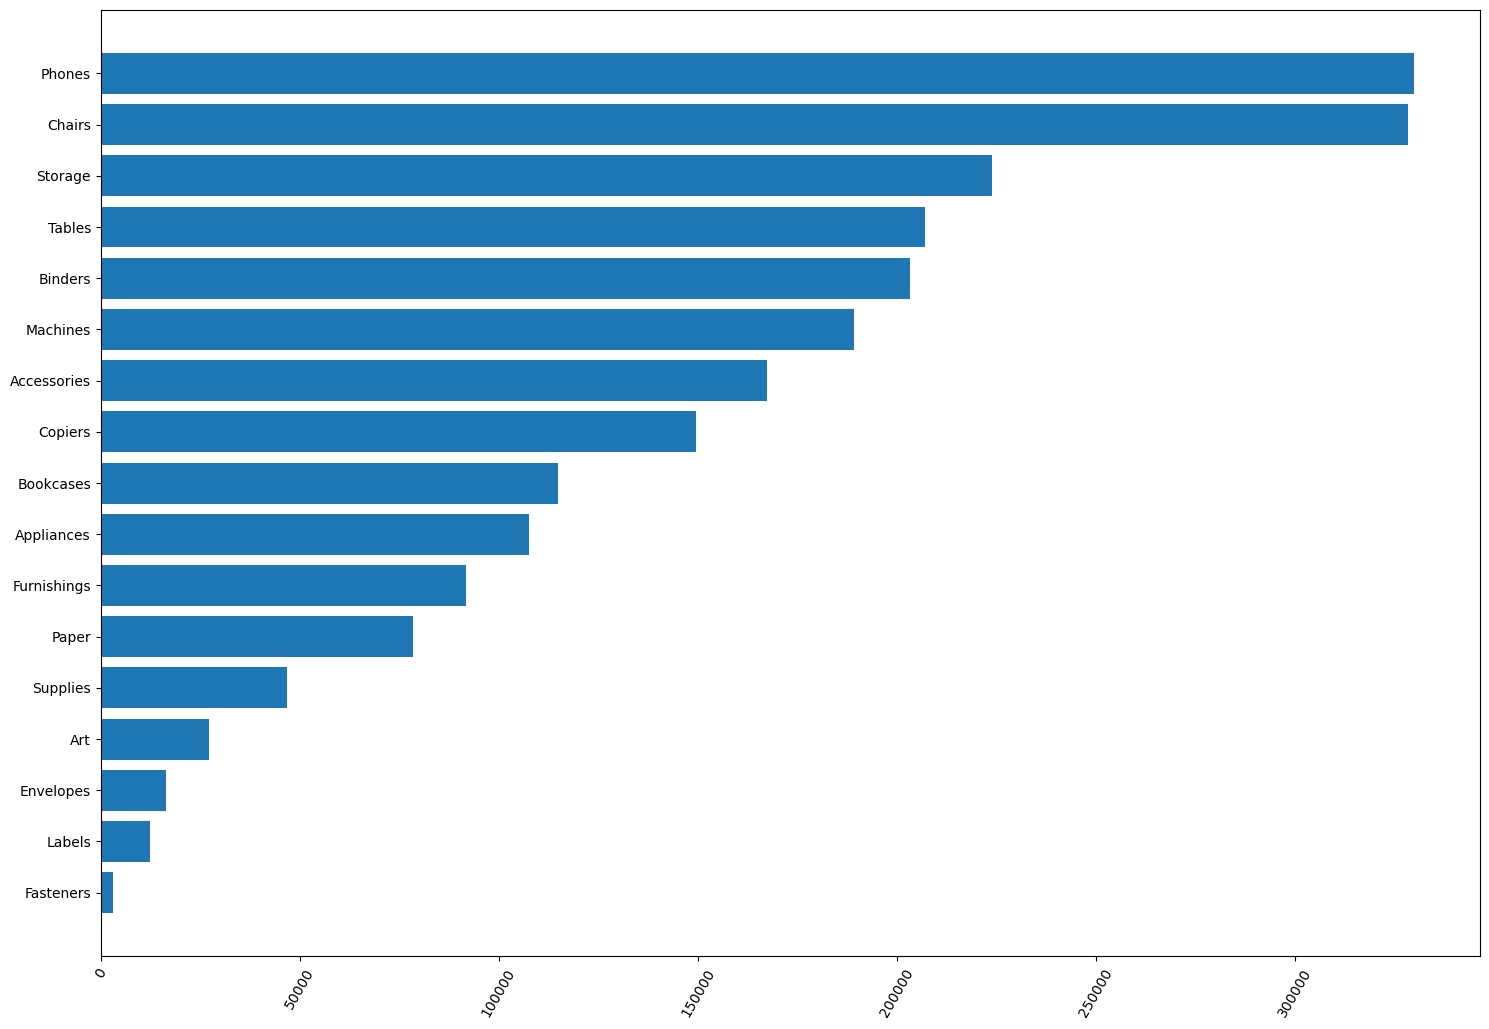

In [401]:
Sub_Category_chart = Sub_Category_chart.reset_index()
Sub_Category_chart = Sub_Category_chart.sort_values('revenue',ascending=True)
plt.figure(figsize=(15,10))
plt.barh(Sub_Category_chart['Sub-Category'],Sub_Category_chart['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [402]:
Segemnt_chart = df.groupby('Segment').agg(
    orders = ('Order ID','nunique'),
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    profit = ('Profit','sum')
)
Segemnt_chart = others(Segemnt_chart)
Segemnt_chart

,orders,revenue,Quantity,profit,revenue_%,aov,margin_%
Segment,,,,,,,
Consumer,2586,1.161401e+06,19521,134119.2092,50.56,23186.29,11.55
Corporate,1514,7.061464e+05,11608,91979.1340,30.74,14097.55,13.03
Home Office,909,4.296531e+05,6744,60298.6785,18.70,8577.62,14.03


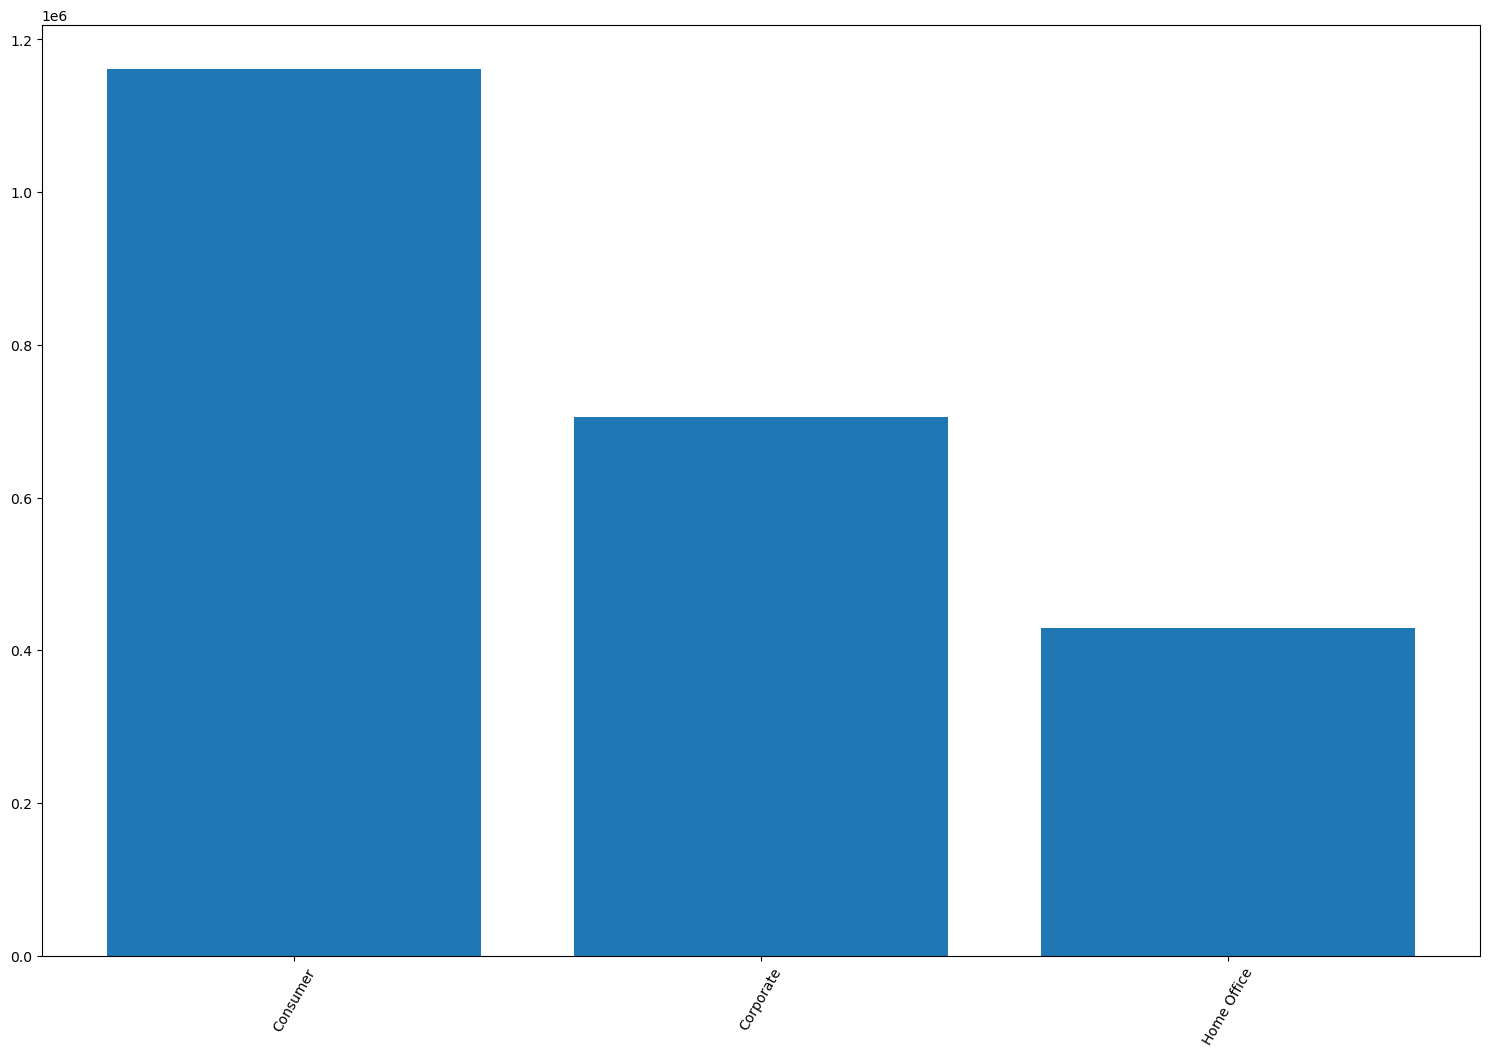

In [403]:

plt.figure(figsize=(15,10))
plt.bar(Segemnt_chart.index,Segemnt_chart['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [404]:

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month_name()
df['time'] = df['Order Date'].dt.to_period('M')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,time
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,2015-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,January,2014-01
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,February,2017-02
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,February,2017-02
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,February,2017-02


In [ ]:

montly_sales = df.groupby('time').agg(
     revenue = ('Sales','sum'),
     profit = ('Profit','sum'),
     Transaction = ('Order ID','count')
).sort_index()

montly_sales.sort_values('profit',ascending=False)
display(montly_sales.nsmallest(10,'profit'))
montly_sales.nlarget
display()

,revenue,profit,Transaction
time,,,
2015-01,18174.0756,-3281.0070,58
2014-07,33946.3930,-841.4826,143
2014-03,55691.0090,498.7299,157
2014-02,4519.8920,862.3084,46
2017-04,36521.5361,933.2900,203
2017-02,20301.1334,1613.8720,107
2016-08,31115.3743,2062.0693,176
2014-01,14236.8950,2450.1907,79
2014-05,23648.2870,2738.7096,122


AttributeError: 'DataFrame' object has no attribute 'ntallest'

C:\Users\nitin\AppData\Local\Temp\ipykernel_21928\1482968048.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


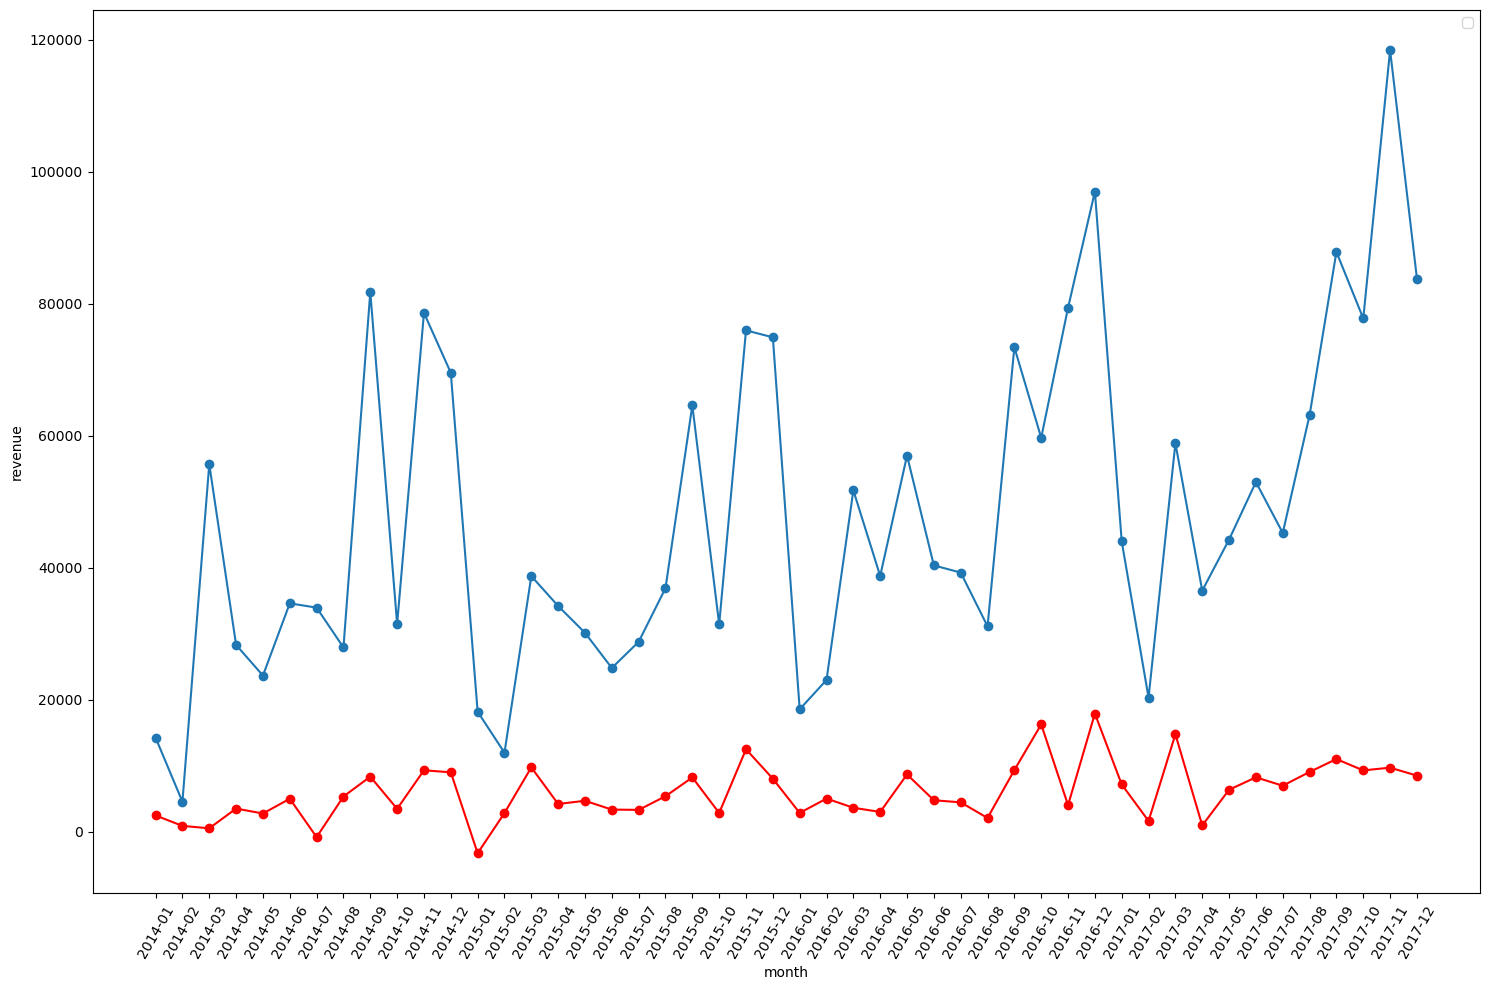

In [406]:

plt.figure(figsize=(15,10))
plt.plot(montly_sales.index.astype(str),montly_sales['revenue'],marker='o')
plt.plot(montly_sales.index.astype(str),montly_sales['profit'],marker='o',color='red')
plt.xlabel('month')
plt.ylabel('revenue')
plt.xticks(rotation=60)
plt.tight_layout()
plt.legend()
plt.show()

In [407]:
customer_sales =  df.groupby('Customer ID').agg(
    orders = ('Order ID','nunique'),
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
     profit = ('Profit','sum'),
    
).sort_values('revenue',ascending=False)
customer_sales = others(customer_sales)
display(customer_sales.head(5))
display(customer_sales.tail(5))


,orders,revenue,Quantity,profit,revenue_%,aov,margin_%
Customer ID,,,,,,,
SM-20320,5,25043.050,50,-1980.7393,1.09,499.96,-7.91
TC-20980,5,19052.218,42,8981.3239,0.83,380.36,47.14
RB-19360,6,15117.339,71,6976.0959,0.66,301.80,46.15
TA-21385,4,14595.620,36,4703.7883,0.64,291.39,32.23
AB-10105,10,14473.571,73,5444.8055,0.63,288.95,37.62


,orders,revenue,Quantity,profit,revenue_%,aov,margin_%
Customer ID,,,,,,,
RS-19870,2,22.328,10,9.5838,0.0,0.45,42.92
MG-18205,1,16.739,8,-1.2453,0.0,0.33,-7.44
CJ-11875,1,16.520,5,1.6520,0.0,0.33,10.00
LD-16855,1,5.304,3,0.4641,0.0,0.11,8.75
TS-21085,2,4.833,4,-3.3156,0.0,0.10,-68.60


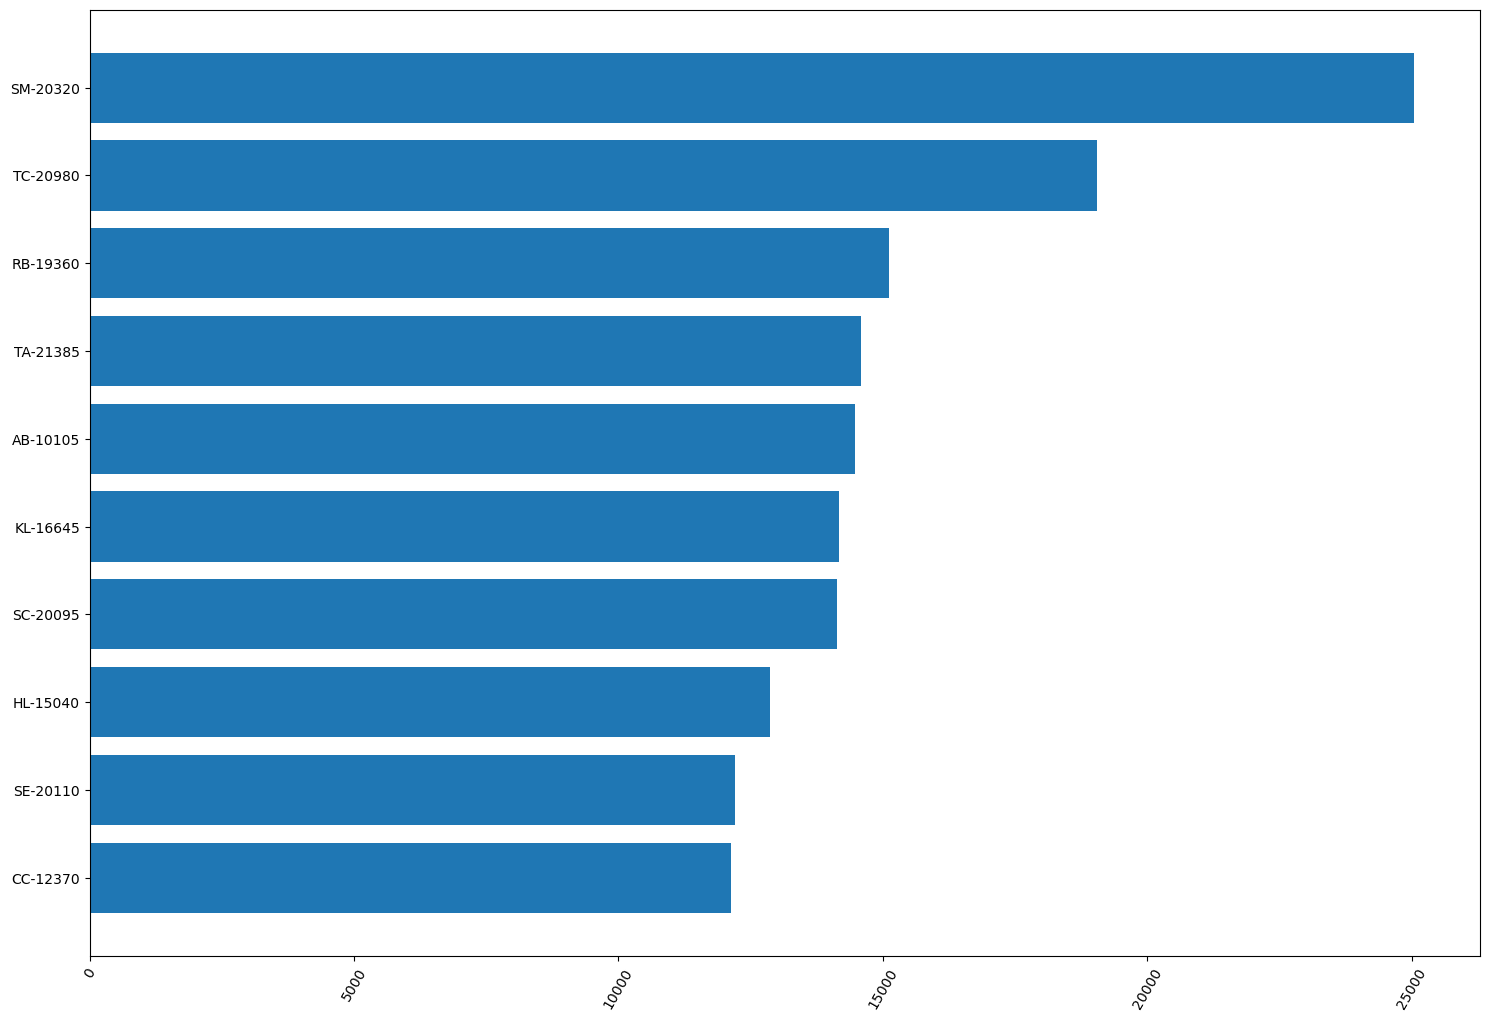

In [408]:
top10 = customer_sales.head(10).sort_values('revenue',ascending=True)
plt.figure(figsize=(15,10))
plt.barh(top10.index,top10['revenue'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [409]:
ship_mode =  df.groupby('Ship Mode').agg(
    order_id = ('Order ID','count'),
    revenue = ('Sales','sum'),
    Quantity = ('Quantity','sum'),
    
).sort_values('revenue',ascending=True)
ship_mode['order%'] = (ship_mode['order_id'] / ship_mode['order_id'].sum() *100 ).round(2)
ship_mode.sort_values('revenue',ascending=False)

,order_id,revenue,Quantity,order%
Ship Mode,,,,
Standard Class,5968,1.358216e+06,22797,59.72
Second Class,1945,4.591936e+05,7423,19.46
First Class,1538,3.514284e+05,5693,15.39
Same Day,543,1.283631e+05,1960,5.43


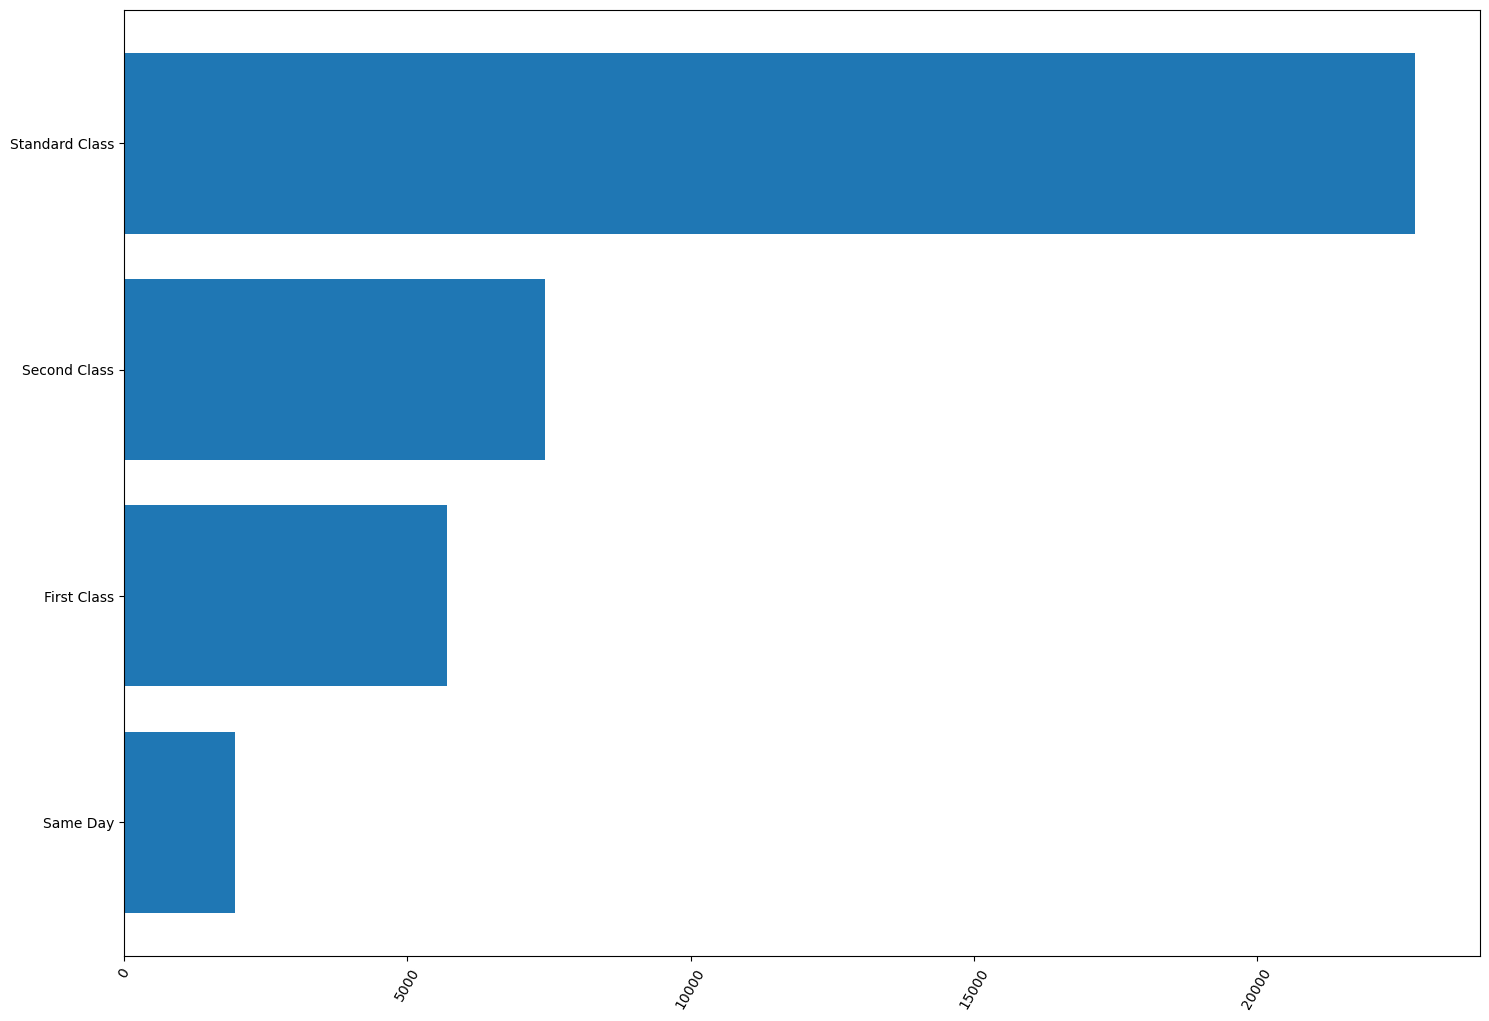

In [410]:
plt.figure(figsize=(15,10))
plt.barh(ship_mode.index,ship_mode['Quantity'])
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()